In [ ]:
# Week 4 Assignment
## Cox-Ross-Rubinstein (CRR) American Put Option Pricing

Name: Vaishali Karande

In [10]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [11]:
import math

def crr_put_price(S0, K, T, r, sigma, steps, american=True):

    dt = T / steps

    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u

    p = (math.exp(r * dt) - d) / (u - d)

    discount = math.exp(-r * dt)

    stock = [S0 * (u**j) * (d**(steps-j))
             for j in range(steps+1)]

    option = [max(K-s,0) for s in stock]

    for i in range(steps-1,-1,-1):

        new_option=[]

        for j in range(i+1):

            continuation = discount * (
                p*option[j+1] +
                (1-p)*option[j]
            )

            if american:

                stock_price = S0*(u**j)*(d**(i-j))

                exercise = max(K-stock_price,0)

                value = max(exercise,continuation)

            else:

                value = continuation

            new_option.append(value)

        option = new_option

    return option[0]

In [12]:
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.25
steps = 500

american = crr_put_price(S0,K,T,r,sigma,steps,True)

european = crr_put_price(S0,K,T,r,sigma,steps,False)

print("American Put =",american)

print("European Put =",european)

print("Early Exercise Premium =",american-european)

American Put = 7.972371262310154
European Put = 7.45399852394807
Early Exercise Premium = 0.5183727383620838


In [13]:
print("Test 1")

print(american>=european)

print()

print("Test 2")

print(crr_put_price(80,K,T,r,sigma,500,True))

print(crr_put_price(100,K,T,r,sigma,500,True))

print(crr_put_price(120,K,T,r,sigma,500,True))

print()

print("Test 3")

print(crr_put_price(100,K,T,r,0.20,500,True))

print(crr_put_price(100,K,T,r,0.25,500,True))

print(crr_put_price(100,K,T,r,0.30,500,True))

Test 1
True

Test 2
20.362458108585194
7.972371262310154
2.649422316446667

Test 3
6.088810110703037
7.972371262310154
9.867327360098823


In [14]:
step_list=[25,50,100,200,500,1000]

print("Steps\tAmerican Put")

for s in step_list:

    price=crr_put_price(100,100,1,0.05,0.25,s,True)

    print(s,"\t",round(price,4))

Steps	American Put
25 	 8.0527
50 	 7.952
100 	 7.9636
200 	 7.9691
500 	 7.9724
1000 	 7.9734


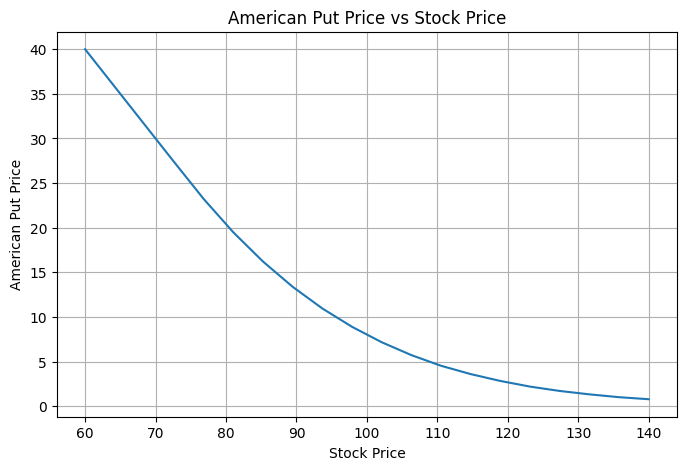

In [15]:
S=np.linspace(60,140,20)

prices=[]

for x in S:

    prices.append(crr_put_price(x,100,1,0.05,0.25,100,True))

plt.figure(figsize=(8,5))

plt.plot(S,prices)

plt.xlabel("Stock Price")

plt.ylabel("American Put Price")

plt.title("American Put Price vs Stock Price")

plt.grid()

plt.show()

In [16]:
boundary=[]

S=np.linspace(60,140,20)

for x in S:

    intrinsic=max(100-x,0)

    option=crr_put_price(x,100,1,0.05,0.25,100,True)

    if abs(option-intrinsic)<0.5:

        boundary.append((x,option))

print(boundary)

[(np.float64(60.0), np.float64(40.0)), (np.float64(64.21052631578948), np.float64(35.78947368421052)), (np.float64(68.42105263157895), np.float64(31.578947368421055)), (np.float64(72.63157894736842), np.float64(27.368421052631575)), (np.float64(76.84210526315789), np.float64(23.212101673304232))]


The American put option is always worth at least as much as the European put because it provides the flexibility of early exercise. Early exercise becomes more attractive when the option is deep in-the-money and little time value remains. The convergence table also shows that increasing the number of binomial steps produces more stable and accurate prices, confirming the reliability of the CRR model.